In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib



In [2]:
!pip install xgboost


In [3]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [4]:
def predict_patient(model_name, sample):
    model = models[model_name]["model"]
    scaler = models[model_name]["scaler"]

    # Ensure input is a DataFrame
    if not isinstance(sample, pd.DataFrame):
        sample = pd.DataFrame([sample], columns=models[model_name]["features"])

    sample_scaled = scaler.transform(sample)
    pred = model.predict(sample_scaled)[0]
    prob = model.predict_proba(sample_scaled)[0][1]
    return pred, prob


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


import joblib


In [22]:
import pandas as pd
import requests
from io import StringIO
from sklearn.datasets import load_breast_cancer

# Diabetes dataset
url_diabetes = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns_diabetes = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]
resp = requests.get(url_diabetes)
df_diabetes = pd.read_csv(StringIO(resp.text), names=columns_diabetes)

# Heart dataset — using working gist URL
url_heart = "https://gist.githubusercontent.com/trantuyen082001/1fc2f5c0ad1507f40e721e6d18b34138/raw/heart.csv"
df_heart = pd.read_csv(url_heart)
# Look at first few rows
df_heart.head()

# Cancer dataset (sklearn built-in)
data_cancer = load_breast_cancer(as_frame=True)
df_cancer = data_cancer.frame

print("✅ Datasets Loaded Successfully!")
print("Diabetes shape:", df_diabetes.shape)
print("Heart shape:", df_heart.shape)
print("Cancer shape:", df_cancer.shape)


✅ Datasets Loaded Successfully!
Diabetes shape: (768, 9)
Heart shape: (303, 14)
Cancer shape: (569, 31)


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier

def train_and_evaluate(df, target_column, model_name):
    print(f"\n==== Training for {model_name.upper()} ====")
    
    # Features & target
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # === Base Models ===
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    rf = RandomForestClassifier(random_state=42)
    svm = SVC(probability=True, random_state=42)
    gb = GradientBoostingClassifier(random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    mlp = MLPClassifier(hidden_layer_sizes=(50,30), max_iter=1000, random_state=42)

    try:
        from xgboost import XGBClassifier
        xgb = XGBClassifier(eval_metric="logloss", random_state=42)

    except ImportError:
        xgb = None
        print("⚠️ XGBoost not installed. Skipping XGBClassifier.")

    # === Hyperparameter tuning (GridSearch) ===
    print("\n🔎 Tuning Random Forest...")
    rf_params = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring="accuracy", n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    rf_best = rf_grid.best_estimator_
    print("✅ Best RF params:", rf_grid.best_params_)

    print("\n🔎 Tuning SVM...")
    svm_params = {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"]}
    svm_grid = GridSearchCV(svm, svm_params, cv=3, scoring="accuracy", n_jobs=-1)
    svm_grid.fit(X_train_scaled, y_train)
    svm_best = svm_grid.best_estimator_
    print("✅ Best SVM params:", svm_grid.best_params_)

    if xgb:
        print("\n🔎 Tuning XGBoost...")
        xgb_params = {"n_estimators": [100, 200], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}
        xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="accuracy", n_jobs=-1)
        xgb_grid.fit(X_train, y_train)
        xgb_best = xgb_grid.best_estimator_
        print("✅ Best XGB params:", xgb_grid.best_params_)
    else:
        xgb_best = None

    # === Train all models (best versions where applicable) ===
    models_to_train = [
        ("Logistic Regression", log_reg, X_train_scaled, X_test_scaled),
        ("Random Forest (Tuned)", rf_best, X_train, X_test),
        ("SVM (Tuned)", svm_best, X_train_scaled, X_test_scaled),
        ("Gradient Boosting", gb, X_train, X_test),
        ("KNN", knn, X_train_scaled, X_test_scaled),
        ("Neural Network", mlp, X_train_scaled, X_test_scaled)
    ]
    if xgb_best:
        models_to_train.append(("XGBoost (Tuned)", xgb_best, X_train, X_test))

    trained_models = {}
    for name, model, Xtr, Xte in models_to_train:
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        y_proba = model.predict_proba(Xte)[:,1]

        trained_models[name] = model

        print(f"\n--- {name} ---")
        print(classification_report(y_test, y_pred))
        print("ROC AUC:", roc_auc_score(y_test, y_proba))

        # Confusion Matrix
        ConfusionMatrixDisplay.from_estimator(model, Xte, y_test, cmap="Blues")
        plt.title(f"{model_name.upper()} - {name} Confusion Matrix")
        plt.show()

        # ROC Curve
        RocCurveDisplay.from_estimator(model, Xte, y_test)
        plt.title(f"{model_name.upper()} - {name} ROC Curve")
        plt.show()

    # === Voting Ensemble ===
    estimators = [(n, trained_models[n]) for n in trained_models.keys()]
    ensemble = VotingClassifier(estimators=estimators, voting="soft")
    ensemble.fit(X_train_scaled, y_train)
    y_pred = ensemble.predict(X_test_scaled)
    print("\n=== Voting Ensemble ===")
    print(classification_report(y_test, y_pred))
    print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))

    # Save best Random Forest and Ensemble
    joblib.dump(rf_best, f"{model_name}_model.joblib")
    joblib.dump(ensemble, f"{model_name}_ensemble.joblib")
    joblib.dump(scaler, f"{model_name}_scaler.joblib")
    print(f"✅ Saved {model_name}_model.joblib (RF tuned), {model_name}_ensemble.joblib (Voting), and scaler")



==== Training for DIABETES ====

🔎 Tuning Random Forest...
✅ Best RF params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🔎 Tuning SVM...
✅ Best SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

🔎 Tuning XGBoost...
✅ Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

ROC AUC: 0.812962962962963


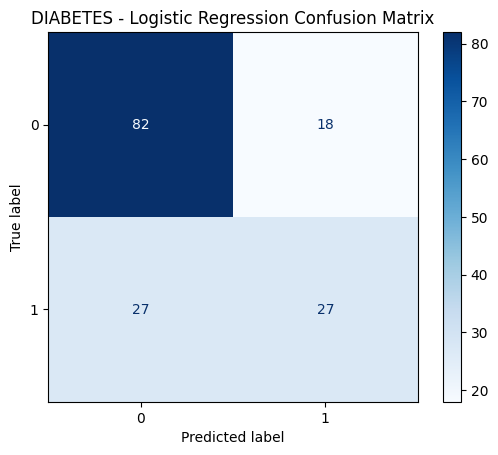

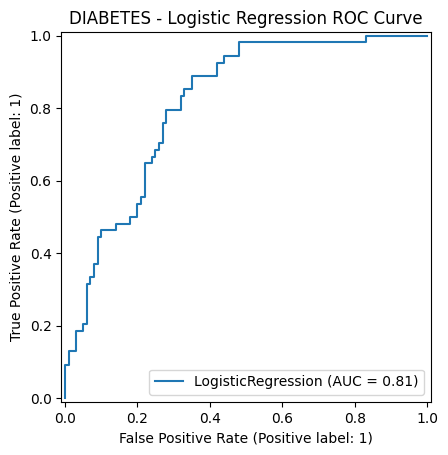


--- Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154

ROC AUC: 0.8157407407407407


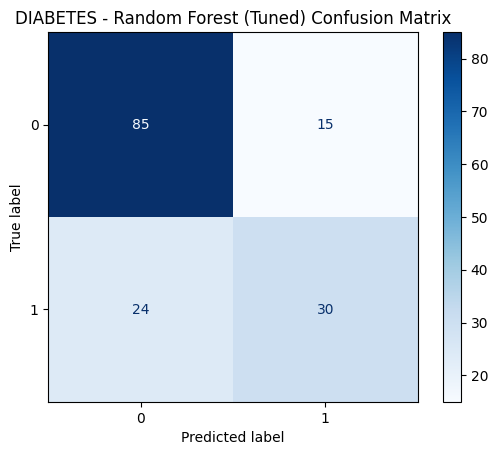

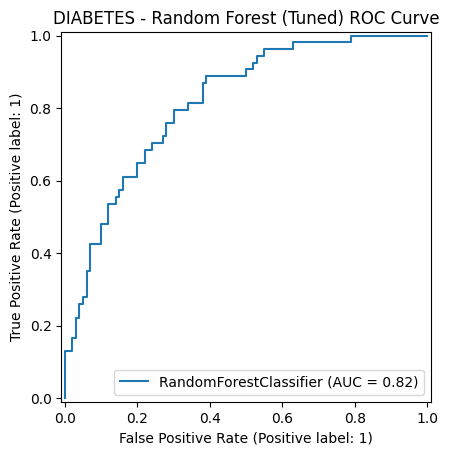


--- SVM (Tuned) ---
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154

ROC AUC: 0.8131481481481482


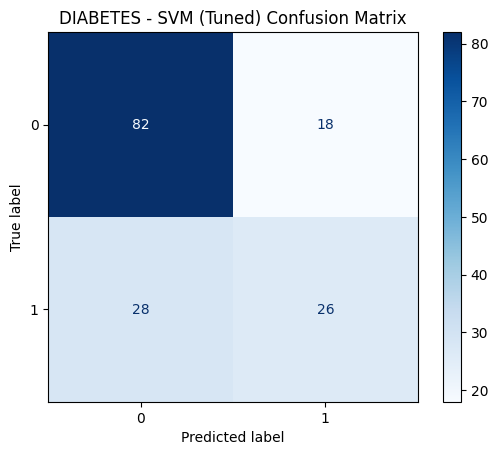

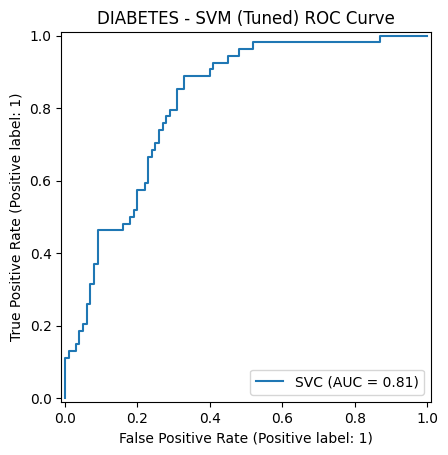


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154

ROC AUC: 0.8314814814814814


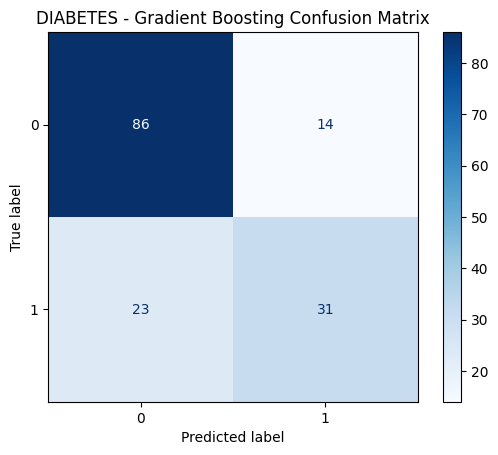

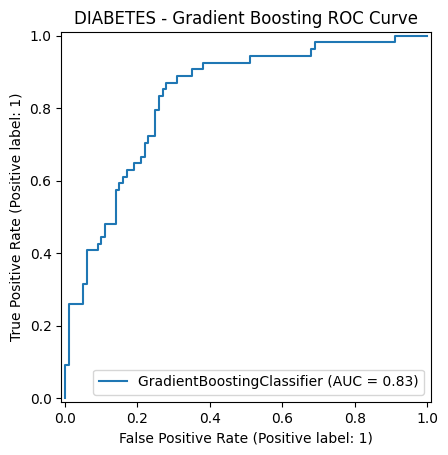


--- KNN ---
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

ROC AUC: 0.7886111111111112


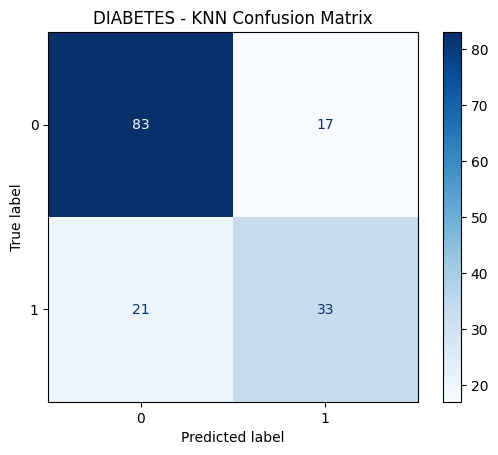

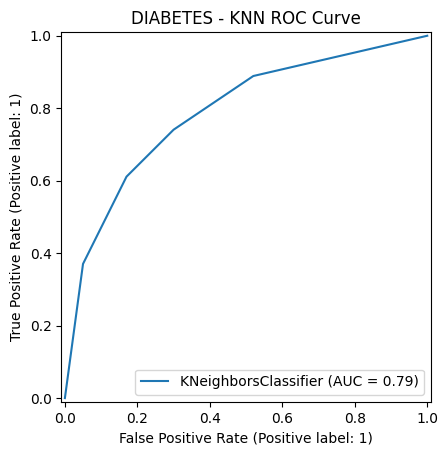


--- Neural Network ---
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154

ROC AUC: 0.8238888888888889


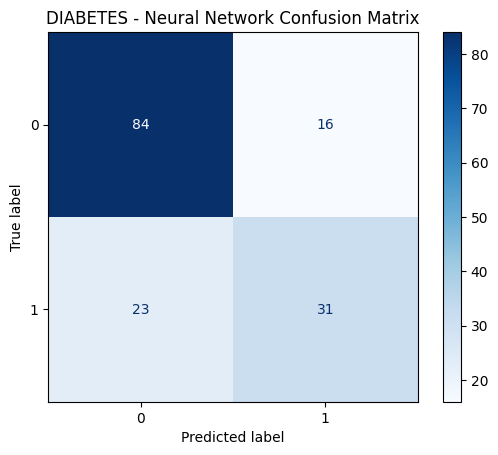

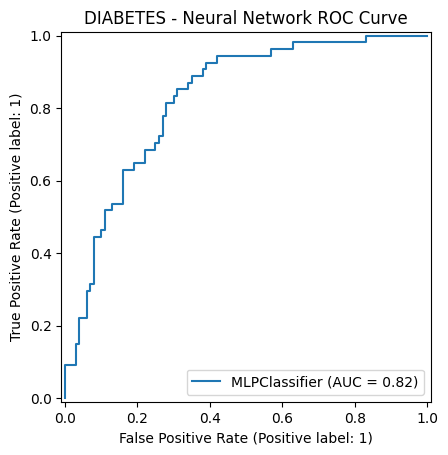


--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       100
           1       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154

ROC AUC: 0.8214814814814815


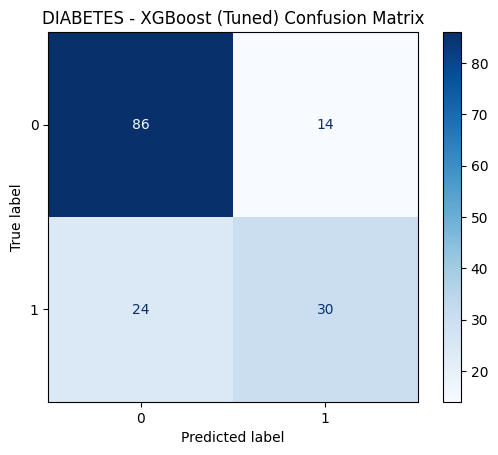

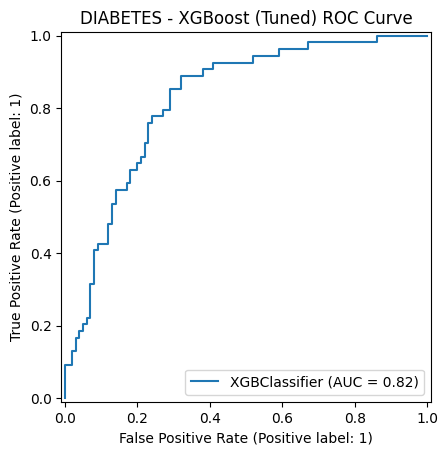


=== Voting Ensemble ===
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154

Ensemble Accuracy: 0.7467532467532467
✅ Saved diabetes_model.joblib (RF tuned), diabetes_ensemble.joblib (Voting), and scaler


In [8]:
from sklearn.metrics import accuracy_score

# Clean diabetes dataset (replace 0 with NaN in some cols)
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_diabetes[cols_with_zero] = df_diabetes[cols_with_zero].replace(0, np.nan)
df_diabetes[cols_with_zero] = SimpleImputer(strategy="median").fit_transform(df_diabetes[cols_with_zero])

train_and_evaluate(df_diabetes, "Outcome", "diabetes")



==== Training for HEART ====

🔎 Tuning Random Forest...
✅ Best RF params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🔎 Tuning SVM...
✅ Best SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

🔎 Tuning XGBoost...
✅ Best XGB params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC AUC: 0.8690476190476191


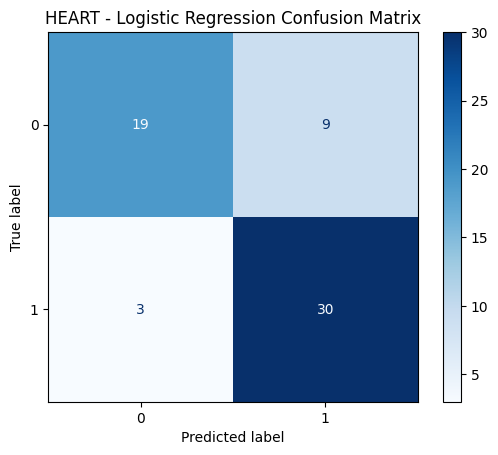

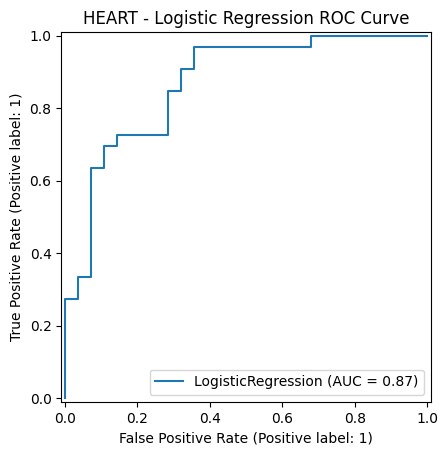


--- Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.95      0.71      0.82        28
           1       0.80      0.97      0.88        33

    accuracy                           0.85        61
   macro avg       0.88      0.84      0.85        61
weighted avg       0.87      0.85      0.85        61

ROC AUC: 0.9058441558441559


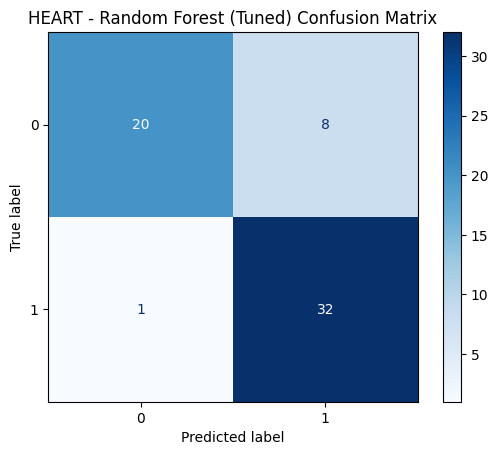

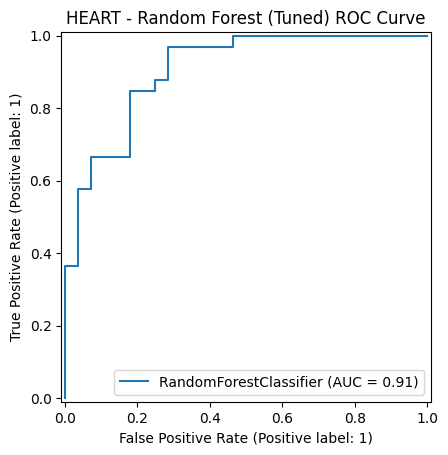


--- SVM (Tuned) ---
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

ROC AUC: 0.8841991341991342


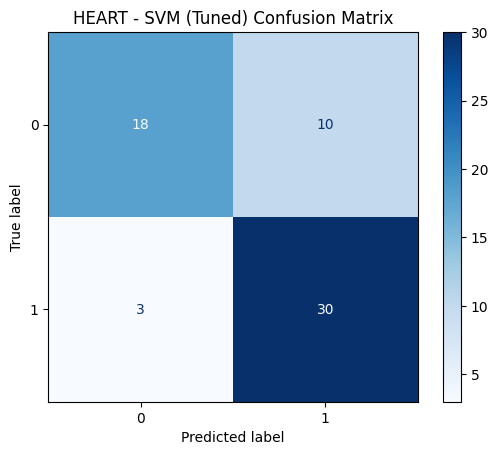

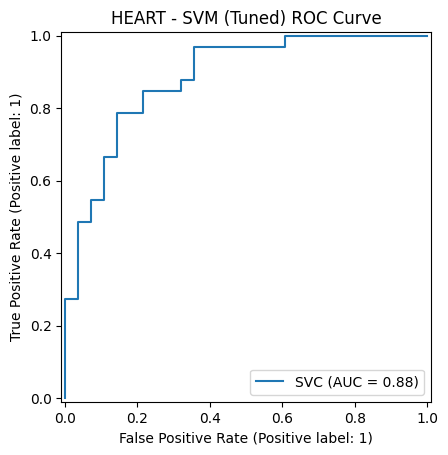


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

ROC AUC: 0.8787878787878788


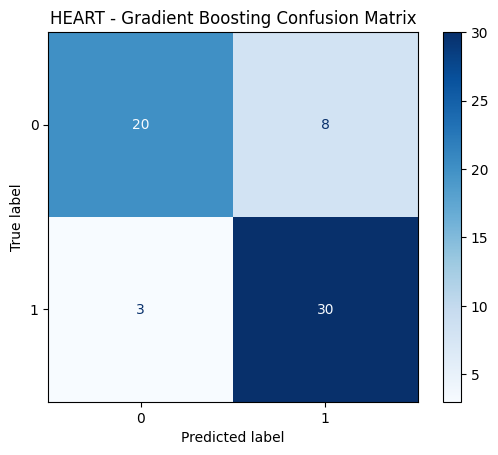

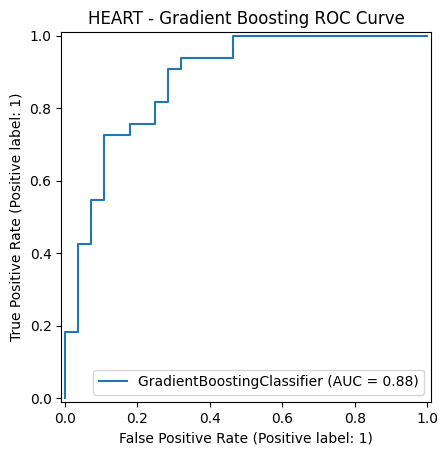


--- KNN ---
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC AUC: 0.8630952380952381


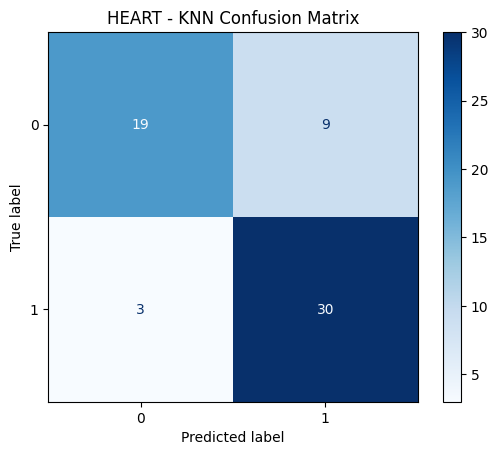

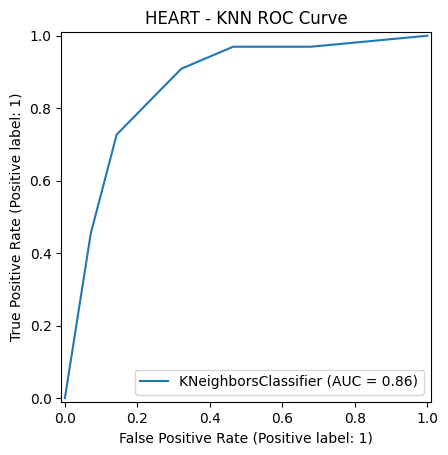


--- Neural Network ---
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

ROC AUC: 0.8495670995670995


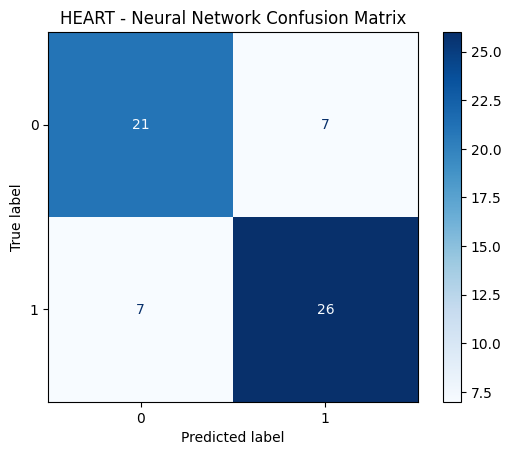

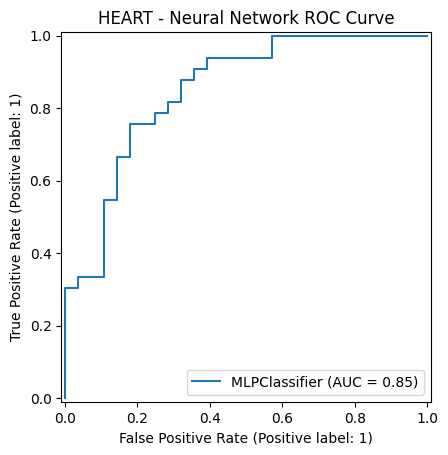


--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC AUC: 0.8571428571428572


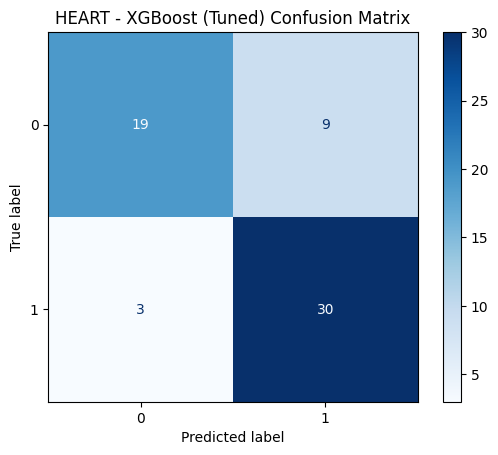

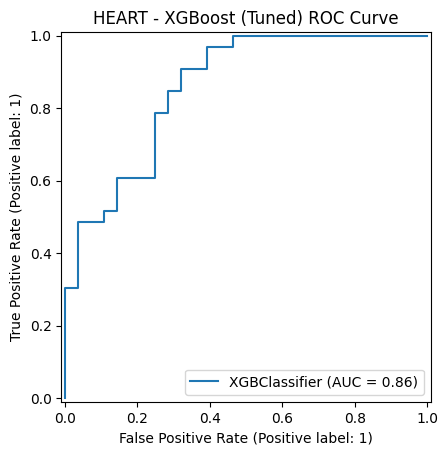


=== Voting Ensemble ===
              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61

Ensemble Accuracy: 0.7704918032786885
✅ Saved heart_model.joblib (RF tuned), heart_ensemble.joblib (Voting), and scaler


In [9]:
# Clean Heart dataset
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# Replace NaN with median for numeric columns
imputer_heart = SimpleImputer(strategy="median")
df_heart[:] = imputer_heart.fit_transform(df_heart)

train_and_evaluate(df_heart, "output", "heart")



==== Training for CANCER ====

🔎 Tuning Random Forest...
✅ Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

🔎 Tuning SVM...
✅ Best SVM params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

🔎 Tuning XGBoost...
✅ Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC AUC: 0.9953703703703703


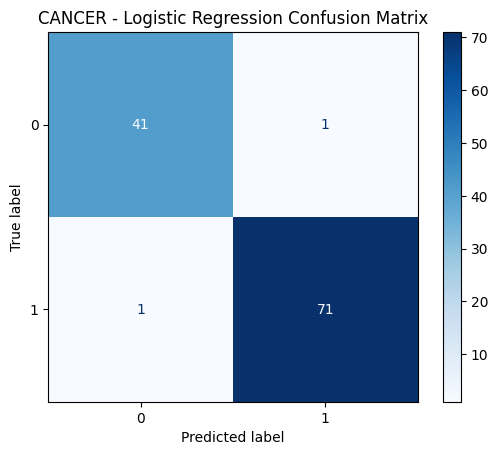

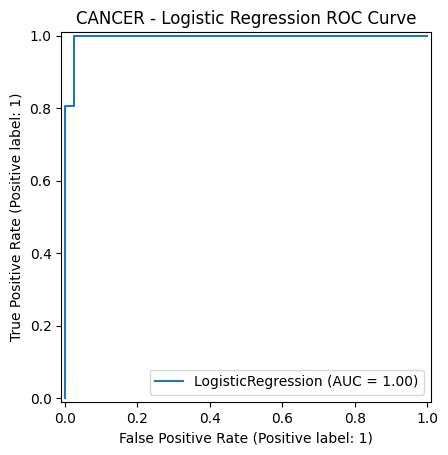


--- Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

ROC AUC: 0.9933862433862434


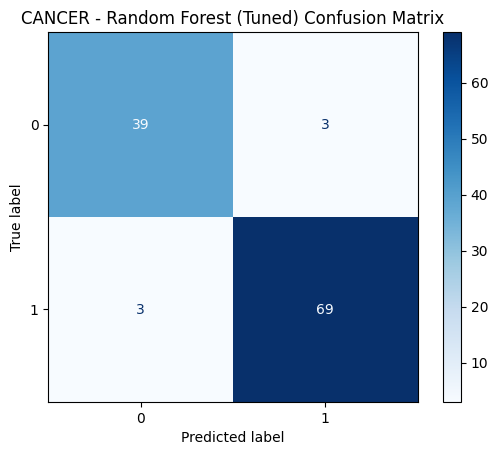

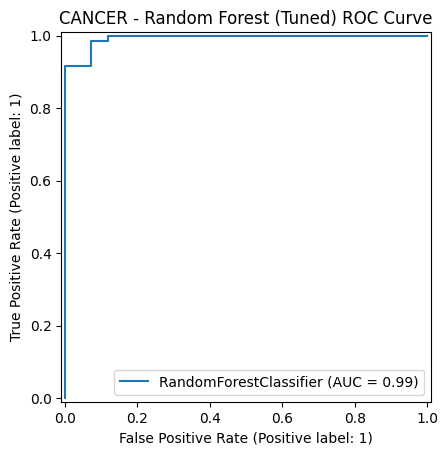


--- SVM (Tuned) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC AUC: 0.9937169312169313


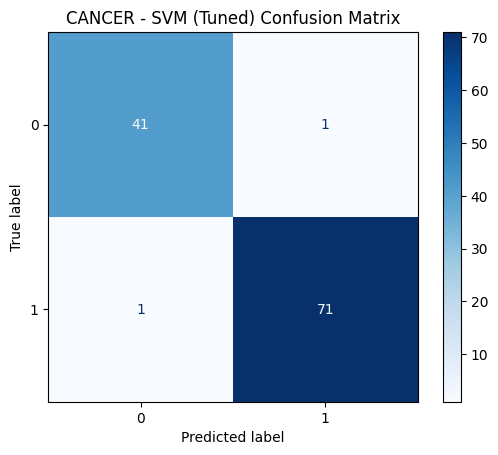

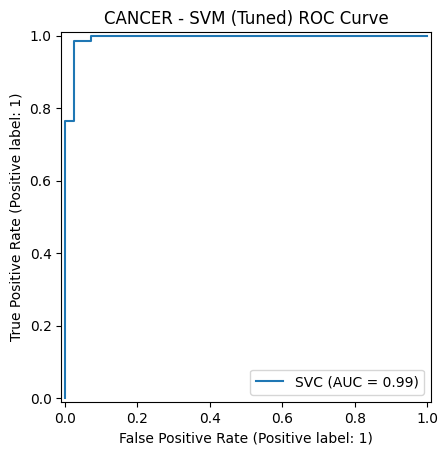


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC AUC: 0.9907407407407408


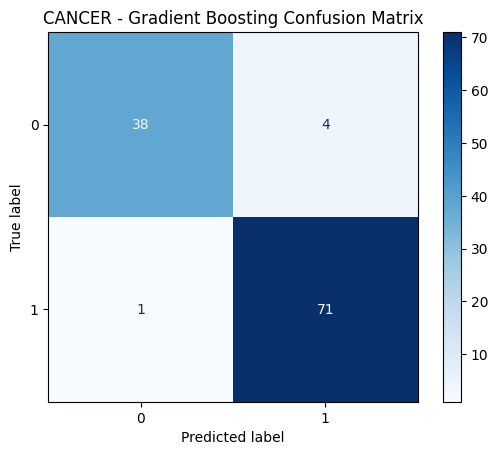

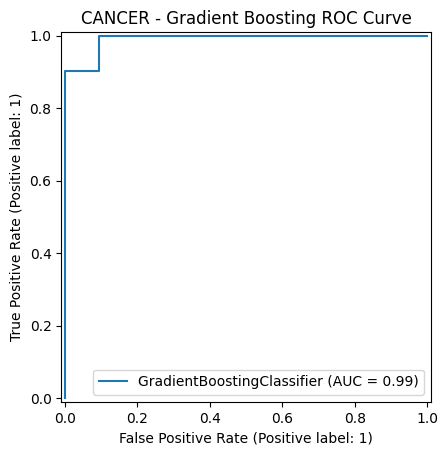


--- KNN ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC AUC: 0.9788359788359788


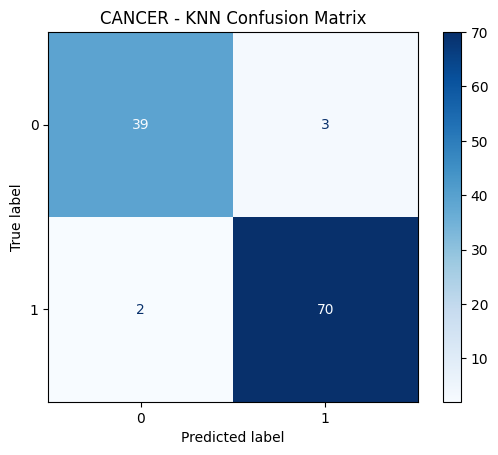

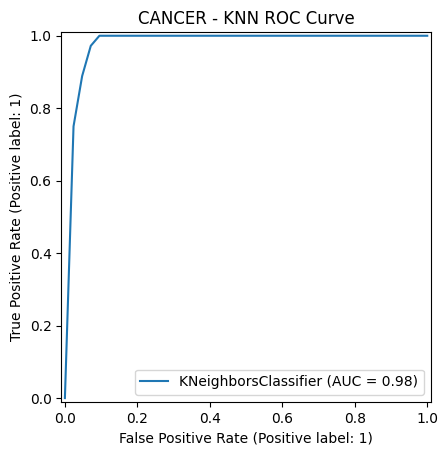


--- Neural Network ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

ROC AUC: 0.9927248677248678


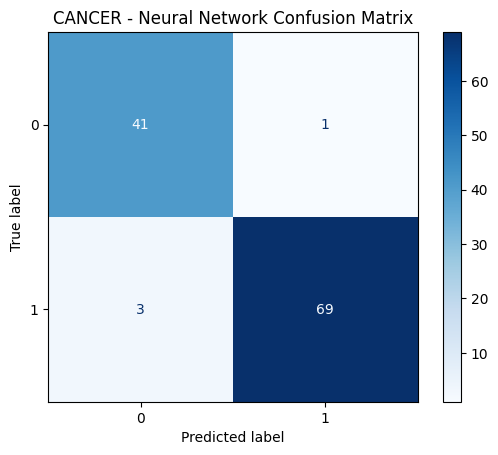

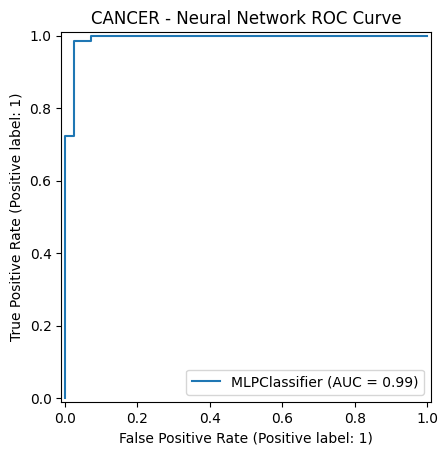


--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

ROC AUC: 0.9943783068783069


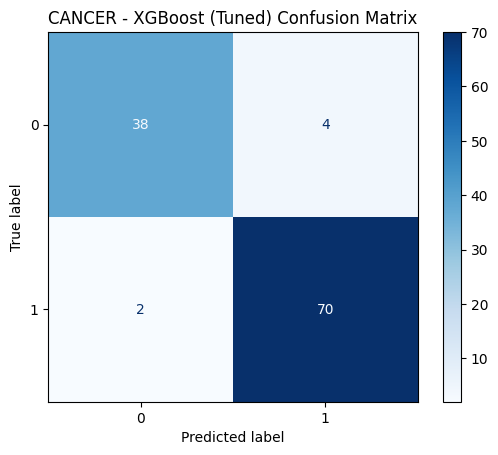

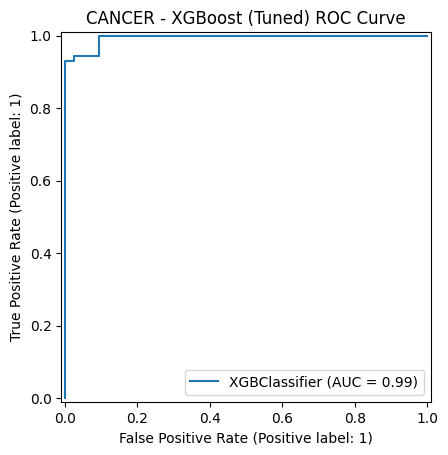


=== Voting Ensemble ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Ensemble Accuracy: 0.9649122807017544
✅ Saved cancer_model.joblib (RF tuned), cancer_ensemble.joblib (Voting), and scaler


In [10]:
from sklearn.metrics import accuracy_score

# Clean Cancer dataset
imputer_cancer = SimpleImputer(strategy="median")
df_cancer[:] = imputer_cancer.fit_transform(df_cancer)

train_and_evaluate(df_cancer, "target", "cancer")


In [11]:
import joblib
import os

MODEL_FOLDER = r"C:\Users\User\Desktop\Early_Disease_Detection"

def predict_patient(model_name, input_data):
    model_path = os.path.join(MODEL_FOLDER, f"{model_name}_model.joblib")
    scaler_path = os.path.join(MODEL_FOLDER, f"{model_name}_scaler.joblib")

    # Load model and scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    # Scale input and predict
    input_scaled = scaler.transform([input_data])
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]

    return pred, prob


In [12]:
# Diabetes example
sample_diabetes = df_diabetes.drop("Outcome", axis=1).iloc[[0]]
pred, prob = predict_patient("diabetes", sample_diabetes.values[0])
print("Diabetes" if pred==1 else "No Diabetes", "| Probability:", round(prob,2))

# Heart example
sample_heart = df_heart.drop("output", axis=1).iloc[[0]]
pred, prob = predict_patient("heart", sample_heart.values[0])
print("Heart Disease" if pred==1 else "Healthy", "| Probability:", round(prob,2))

# Cancer example
sample_cancer = df_cancer.drop("target", axis=1).iloc[[0]]
pred, prob = predict_patient("cancer", sample_cancer.values[0])
print("Malignant Cancer" if pred==1 else "Benign", "| Probability:", round(prob,2))


No Diabetes | Probability: 0.06
Heart Disease | Probability: 0.69
Malignant Cancer | Probability: 0.55


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python

In [13]:
def predict_patient(model_name, input_data):
    model = joblib.load(f"{model_name}_model.joblib")
    scaler = joblib.load(f"{model_name}_scaler.joblib")
    
    input_scaled = scaler.transform([input_data])
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]
    return pred, prob


In [14]:
# Diabetes patient
sample_diabetes = [5,116,74,20,79,25.6,0.201,30]
pred, prob = predict_patient("diabetes", sample_diabetes)
print("Diabetes" if pred==1 else "No Diabetes", "| Probability:", round(prob,2))

# Heart patient
sample_heart = [63,1,3,145,233,1,0,150,0,2.3,0,0,1]
pred, prob = predict_patient("heart", sample_heart)
print("Heart Disease" if pred==1 else "Healthy", "| Probability:", round(prob,2))

# Cancer patient
from sklearn.datasets import load_breast_cancer
import pandas as pd
data_cancer = load_breast_cancer(as_frame=True)
df_cancer = data_cancer.frame

# Use correct target column name
sample_cancer = df_cancer.drop("target", axis=1).iloc[0].values
pred, prob = predict_patient("cancer", sample_cancer)
print("Malignant Cancer" if pred==1 else "Benign", "| Probability:", round(prob,2))


No Diabetes | Probability: 0.06
Heart Disease | Probability: 0.69
Malignant Cancer | Probability: 0.55


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python

In [15]:
import os
print(os.getcwd())


C:\Users\User\Desktop\Early_Disease_Detection


In [16]:
os.listdir()


['.gitignore',
 '.ipynb_checkpoints',
 'app.py',
 'cancer_ensemble.joblib',
 'cancer_model.joblib',
 'cancer_scaler.joblib',
 'diabetes_ensemble.joblib',
 'diabetes_model.joblib',
 'diabetes_scaler.joblib',
 'Early_Disease_Detection.ipynb',
 'heart_ensemble.joblib',
 'heart_model.joblib',
 'heart_scaler.joblib',
 'models',
 'README.md',
 'requirements.txt',
 'Untitled.ipynb',
 'Untitled1.ipynb']

In [17]:
from sklearn.metrics import accuracy_score

# Features and target
X_diabetes = df_diabetes.drop("Outcome", axis=1)
y_diabetes = df_diabetes["Outcome"]

# Scale features using the saved scaler
import joblib
import os

MODEL_FOLDER = r"C:\Users\User\Desktop\Early_Disease_Detection"
scaler_diabetes = joblib.load(os.path.join(MODEL_FOLDER, "diabetes_scaler.joblib"))
model_diabetes = joblib.load(os.path.join(MODEL_FOLDER, "diabetes_model.joblib"))

X_scaled = scaler_diabetes.transform(X_diabetes)

# Predict on the dataset
y_pred = model_diabetes.predict(X_scaled)

# Accuracy
acc = accuracy_score(y_diabetes, y_pred)
print("Diabetes Model Accuracy:", round(acc*100,2), "%")


Diabetes Model Accuracy: 65.1 %


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [18]:
# Features and target
X_heart = df_heart.drop("output", axis=1)
y_heart = df_heart["output"]

scaler_heart = joblib.load(os.path.join(MODEL_FOLDER, "heart_scaler.joblib"))
model_heart = joblib.load(os.path.join(MODEL_FOLDER, "heart_model.joblib"))

X_scaled = scaler_heart.transform(X_heart)
y_pred = model_heart.predict(X_scaled)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_heart, y_pred)
print("Heart Model Accuracy:", round(acc*100,2), "%")


Heart Model Accuracy: 76.57 %


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
# Features and target
X_cancer = df_cancer.drop("target", axis=1)
y_cancer = df_cancer["target"]

scaler_cancer = joblib.load(os.path.join(MODEL_FOLDER, "cancer_scaler.joblib"))
model_cancer = joblib.load(os.path.join(MODEL_FOLDER, "cancer_model.joblib"))

X_scaled = scaler_cancer.transform(X_cancer)
y_pred = model_cancer.predict(X_scaled)

acc = accuracy_score(y_cancer, y_pred)
print("Cancer Model Accuracy:", round(acc*100,2), "%")


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Cancer Model Accuracy: 62.74 %
